# Room Occupancy Detection: Linear vs Logistic Regression

## Import Libraries

In [21]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, ConfusionMatrixDisplay,
)

import joblib

sns.set_style("whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## Load Dataset

In [22]:
df = pd.read_csv(r"D:\NTI\Session-09\data\Occupancy.csv")
df.head()

,date,Temperature,Humidity,Light,CO2,HumidityRatio,Occupancy
0,2015-02-02 14:19:00,23.7000,26.272,585.200000,749.200000,0.004764,1
1,2015-02-02 14:19:59,23.7180,26.290,578.400000,760.400000,0.004773,1
2,2015-02-02 14:21:00,23.7300,26.230,572.666667,769.666667,0.004765,1
3,2015-02-02 14:22:00,23.7225,26.125,493.750000,774.750000,0.004744,1
4,2015-02-02 14:23:00,23.7540,26.200,488.600000,779.000000,0.004767,1


In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20560 entries, 0 to 20559
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           20560 non-null  str    
 1   Temperature    20560 non-null  float64
 2   Humidity       20560 non-null  float64
 3   Light          20560 non-null  float64
 4   CO2            20560 non-null  float64
 5   HumidityRatio  20560 non-null  float64
 6   Occupancy      20560 non-null  int64  
dtypes: float64(5), int64(1), str(1)
memory usage: 1.1 MB


In [24]:
df.describe()

,Temperature,Humidity,Light,CO2,HumidityRatio,Occupancy
count,20560.000000,20560.000000,20560.000000,20560.000000,20560.000000,20560.000000
mean,20.906212,27.655925,130.756622,690.553276,0.004228,0.231031
std,1.055315,4.982154,210.430875,311.201281,0.000768,0.421503
min,19.000000,16.745000,0.000000,412.750000,0.002674,0.000000
25%,20.200000,24.500000,0.000000,460.000000,0.003719,0.000000
50%,20.700000,27.290000,0.000000,565.416667,0.004292,0.000000
75%,21.525000,31.290000,301.000000,804.666667,0.004832,0.000000
max,24.408333,39.500000,1697.250000,2076.500000,0.006476,1.000000


## Data Quality Check

In [25]:
print(f"Missing values:\n{df.isnull().sum()}")
print(f"\nDuplicate rows: {df.duplicated().sum()}")

Missing values:
date             0
Temperature      0
Humidity         0
Light            0
CO2              0
HumidityRatio    0
Occupancy        0
dtype: int64

Duplicate rows: 0


## EDA

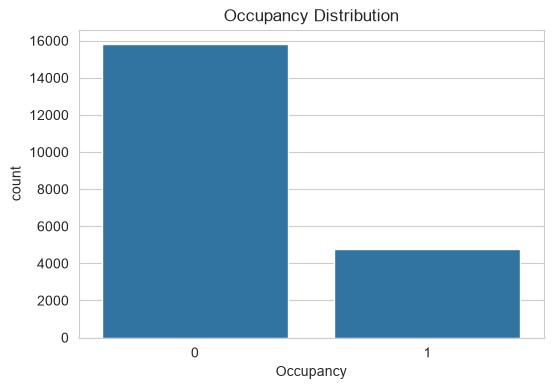

In [26]:
plt.figure(figsize=(6,4))
sns.countplot(x="Occupancy", data=df)
plt.title("Occupancy Distribution")
plt.show()

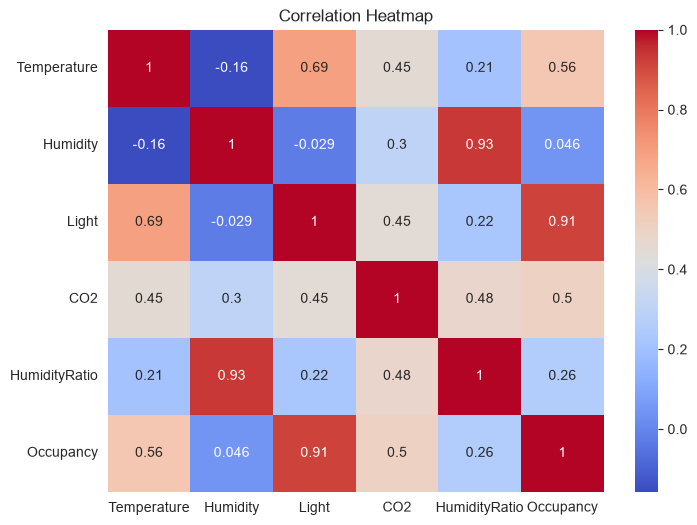

In [27]:
numeric_df = df.drop("date", axis=1)

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## Feature Selection & Train-Test Split

In [28]:
X = df.drop(["date", "Occupancy"], axis=1)
y = df["Occupancy"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Train shape: (16448, 5), Test shape: (4112, 5)


## Feature Scaling

In [29]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Model 1: Linear Regression

Linear Regression outputs continuous values, so we round/threshold at 0.5 to get class predictions.

In [30]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

y_pred_lin_raw = lin_reg.predict(X_test_scaled)
y_pred_lin = (y_pred_lin_raw >= 0.5).astype(int)

acc_lin = accuracy_score(y_test, y_pred_lin)
prec_lin = precision_score(y_test, y_pred_lin)
rec_lin = recall_score(y_test, y_pred_lin)
f1_lin = f1_score(y_test, y_pred_lin)
auc_lin = roc_auc_score(y_test, y_pred_lin_raw)

print(f"Accuracy:  {acc_lin:.4f}")
print(f"Precision: {prec_lin:.4f}")
print(f"Recall:    {rec_lin:.4f}")
print(f"F1 Score:  {f1_lin:.4f}")
print(f"ROC-AUC:   {auc_lin:.4f}")

Accuracy:  0.9844
Precision: 0.9395
Recall:    0.9968
F1 Score:  0.9673
ROC-AUC:   0.9946


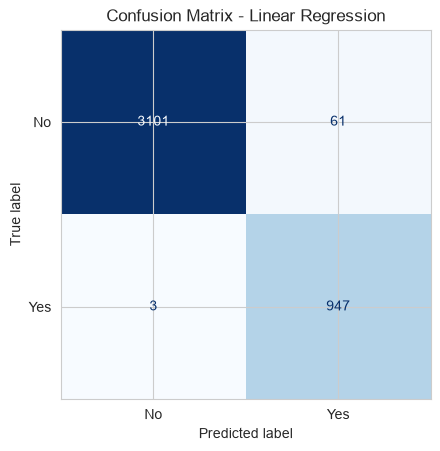

In [31]:
cm_lin = confusion_matrix(y_test, y_pred_lin)
ConfusionMatrixDisplay(cm_lin, display_labels=["No", "Yes"]).plot(cmap="Blues", colorbar=False)
plt.title("Confusion Matrix - Linear Regression")
plt.show()

## Model 2: Logistic Regression

In [32]:
log_reg = LogisticRegression(random_state=RANDOM_STATE)
log_reg.fit(X_train_scaled, y_train)

y_pred_log = log_reg.predict(X_test_scaled)
y_proba_log = log_reg.predict_proba(X_test_scaled)[:, 1]

acc_log = accuracy_score(y_test, y_pred_log)
prec_log = precision_score(y_test, y_pred_log)
rec_log = recall_score(y_test, y_pred_log)
f1_log = f1_score(y_test, y_pred_log)
auc_log = roc_auc_score(y_test, y_proba_log)

print(f"Accuracy:  {acc_log:.4f}")
print(f"Precision: {prec_log:.4f}")
print(f"Recall:    {rec_log:.4f}")
print(f"F1 Score:  {f1_log:.4f}")
print(f"ROC-AUC:   {auc_log:.4f}")

Accuracy:  0.9871
Precision: 0.9526
Recall:    0.9937
F1 Score:  0.9727
ROC-AUC:   0.9951


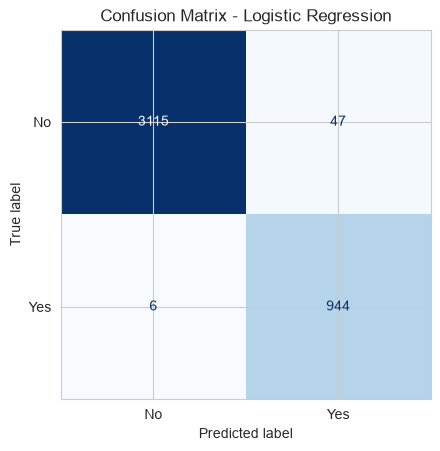

In [33]:
cm_log = confusion_matrix(y_test, y_pred_log)
ConfusionMatrixDisplay(cm_log, display_labels=["No", "Yes"]).plot(cmap="Blues", colorbar=False)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

## Compare Models

In [34]:
comparison = pd.DataFrame([
    {"Model": "Linear Regression", "Accuracy": acc_lin, "Precision": prec_lin, "Recall": rec_lin, "F1 Score": f1_lin, "ROC-AUC": auc_lin},
    {"Model": "Logistic Regression", "Accuracy": acc_log, "Precision": prec_log, "Recall": rec_log, "F1 Score": f1_log, "ROC-AUC": auc_log},
]).sort_values("F1 Score", ascending=False).reset_index(drop=True)

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.987111,0.952573,0.993684,0.972694,0.995070
1,Linear Regression,0.984436,0.939484,0.996842,0.967314,0.994592


In [35]:
best_model_name = comparison.iloc[0]["Model"]
best_model = log_reg if best_model_name == "Logistic Regression" else lin_reg

print(f"Best model: {best_model_name}")

Best model: Logistic Regression


In [36]:
print("Linear Regression Report")
print(classification_report(y_test, y_pred_lin))

print("\nLogistic Regression Report")
print(classification_report(y_test, y_pred_log))

Linear Regression Report
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      3162
           1       0.94      1.00      0.97       950

    accuracy                           0.98      4112
   macro avg       0.97      0.99      0.98      4112
weighted avg       0.99      0.98      0.98      4112


Logistic Regression Report
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      3162
           1       0.95      0.99      0.97       950

    accuracy                           0.99      4112
   macro avg       0.98      0.99      0.98      4112
weighted avg       0.99      0.99      0.99      4112



## Save Best Model

In [37]:
joblib.dump(best_model, "best_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Saved: best_model.pkl")
print("Saved: scaler.pkl")

Saved: best_model.pkl
Saved: scaler.pkl
